In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
import ruptures as rpt
from sklearn.cluster import DBSCAN, HDBSCAN
import multiprocessing
from concurrent import futures
from tqdm import tqdm

import sys

sys.path.append("..")

from src import IOFunctions
from IPython.display import display, clear_output

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SR_F = SR_Functions.SuperRes_Functions()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../Camera_Calibrations/Ximea_Camera"
# data_folder = r'C:\Users\jsb92\Cambridge University Dropbox\Joseph Beckwith\Chemistry\Lee\Data\Salix\Ximea_Calibration'
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

In [2]:
dye_data_folders = np.array(
    [
        r"/media/jbeckwith/Ezra Seagat/JSB/20250520_FRET/data/BSA_50pMDNAHJ/NotchFilter_785SP_10perc561_1/"
    ]
)

In [3]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r488-561-t1-25x36"
dichroic_mirror_all = "semrock-di03-r405-488-561-635-t1-25x36"
shortpass_filter = "semrock-bsp01-785r"
longpass_red_filter = "semrock-blp01-635r"

longpass_blue_filter = "semrock-blp01-488r"
bandpass_488_filter = "semrock-ff01-520-44"
filters = [shortpass_filter, dichroic_mirror_all, notch_filter]
dye = "Cy3"
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
)
dye_pixel_efficiency_Cy3 = dye_pixel_efficiency / np.sum(dye_pixel_efficiency)

In [4]:
dye = "Cy5"
average_emission_wavelengths, dye_pixel_efficiency = (
    S_F.get_pixel_fractions_dye_and_filters(dye, filters, wavelength, pixel_QYs)
)
dye_pixel_efficiency_Cy5 = dye_pixel_efficiency / np.sum(dye_pixel_efficiency)

In [5]:
images = H_F.file_search(dye_data_folders[0], ".tif", "")
metadata = H_F.file_search(dye_data_folders[0], "metadata", "")

In [6]:
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata[0])
n_pages = IO.get_num_pages_in_TIF(images[0])

In [7]:
gain_map = gain[x_coord : x_coord + width, y_coord : y_coord + height]
offset_map = offset[x_coord : x_coord + width, y_coord : y_coord + height]
rqe_map = rqe[x_coord : x_coord + width, y_coord : y_coord + height]
read_noise = readnoise[x_coord : x_coord + width, y_coord : y_coord + height]
variance_map = variance[x_coord : x_coord + width, y_coord : y_coord + height]

In [8]:
masks = M_F.get_ROI_mask(
    ROI_x_start=x_coord, ROI_y_start=y_coord, width=width, height=height
)

In [10]:
raw_data, photoelectron_data, smoothed_data, weights_map = (
    IO.read_tiff_tophotoelectrons(
        file_path=images[0],
        smoothing_function=smoothing_function,
        gain_map=gain_map,
        offset_map=offset_map,
        rqe=rqe_map,
        read_noise=read_noise,
        frame=np.arange(n_pages),
    )
)

In [47]:
first_ten_frames = np.sum(raw_data[:10, :, :], axis=0)

In [69]:
puncta_locations = SD_F.detect_puncta_in_image(
    raw_data[1, :, :], variance=variance_map, pfa=1e-4
)

In [16]:
puncta_locations = SD_F.detect_puncta_in_image(
    photoelectron_data[1, :, :], variance=variance_map, pfa=1e-4
)

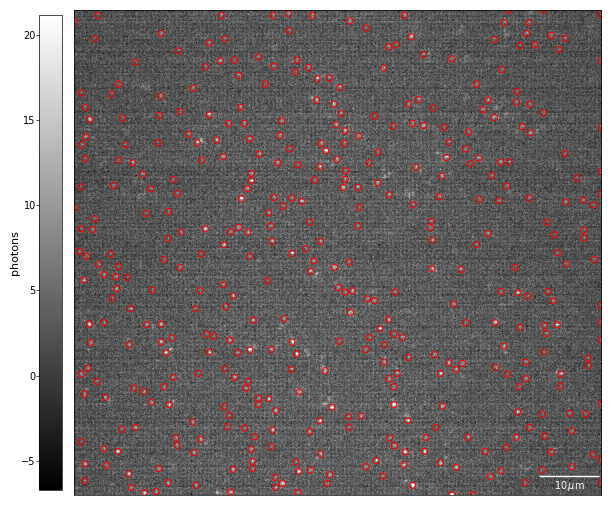

In [17]:
fig, axs = plotter.two_column_plot(width=6, height=6)

axs = plotter.image_scatter_plot(
    axs=axs,
    data=photoelectron_data[1, :, :],
    xdata=puncta_locations[:, 0],
    ydata=puncta_locations[:, 1],
    vmax=np.percentile(photoelectron_data[0, :, :], 99.9),
)
# plt.xlim([300, 500])
# plt.ylim([300, 500])
plt.show()

In [28]:
def create_intensity_colour_traces(image, puncta, masks, ROI=12):
    puncta = puncta.astype("float")
    photoelectron_traces = np.zeros([puncta.shape[0], image.shape[0]])
    R_traces = np.zeros([puncta.shape[0], image.shape[0]])
    G_traces = np.zeros([puncta.shape[0], image.shape[0]])
    B_traces = np.zeros([puncta.shape[0], image.shape[0]])

    for i in np.arange(puncta.shape[0]):
        x_min = int(puncta[i, 0]) - int(ROI / 2)
        x_max = int(puncta[i, 0]) + int(ROI / 2)
        y_min = int(puncta[i, 1]) - int(ROI / 2)
        y_max = int(puncta[i, 1]) + int(ROI / 2)
        coord_array = np.array([x_min, x_max, y_min, y_max])
        x_array = np.array([x_min, x_max])
        y_array = np.array([y_min, y_max])
        if (
            np.any(coord_array < 0)
            or np.any(x_array > image.shape[1])
            or np.any(y_array > image.shape[2])
        ):
            photoelectron_traces[i, :] = np.NAN
            R_traces[i, :] = np.NAN
            G_traces[i, :] = np.NAN
            B_traces[i, :] = np.NAN
            puncta[i, :] = np.NAN
        else:
            mask_R = masks["R"][x_min:x_max, y_min:y_max]
            mask_G = masks["G"][x_min:x_max, y_min:y_max]
            mask_B = masks["B"][x_min:x_max, y_min:y_max]

            photoelectron_traces[i, :] = np.sum(
                np.sum(image[:, x_min:x_max, y_min:y_max], axis=-1), axis=-1
            )
            R_traces[i, :] = np.sum(
                np.sum(image[:, x_min:x_max, y_min:y_max] * mask_R, axis=-1), axis=-1
            )
            G_traces[i, :] = np.sum(
                np.sum(image[:, x_min:x_max, y_min:y_max] * mask_G, axis=-1), axis=-1
            )
            B_traces[i, :] = np.sum(
                np.sum(image[:, x_min:x_max, y_min:y_max] * mask_B, axis=-1), axis=-1
            )

    return (
        puncta[~np.isnan(puncta).any(axis=1), :],
        photoelectron_traces[~np.isnan(photoelectron_traces).any(axis=1), :],
        R_traces[~np.isnan(R_traces).any(axis=1), :],
        G_traces[~np.isnan(G_traces).any(axis=1), :],
        B_traces[~np.isnan(B_traces).any(axis=1), :],
    )

In [14]:
puncta, photoelectron_traces, R_traces, G_traces, B_traces = (
    create_intensity_colour_traces(data, puncta_locations, masks)
)

In [111]:
def CPs_from_futures(fs):
    """
    function to return CPs from a futures object

    Args:
        fs (futures object): object

    Returns:
        frames (np.ndarray): frames
    """
    frames = {}
    results = [_.result() for _ in fs]
    for frame_vals in results:
        if isinstance(frame_vals, list):
            for frame in frame_vals:
                if np.any(np.isnan(frame)):
                    continue
                else:
                    frames[int(frame[0] / 1000)] = np.squeeze(frame)
        else:
            if np.any(np.isnan(frame_vals)):
                continue
            else:
                frames[int(frame_vals[0] / 1000)] = np.squeeze(frame_vals)
    return frames

In [112]:
def find_CPs(photoelectron_data, values):
    frames = []
    for value, i in enumerate(values):
        signal = photoelectron_data[value]
        n = len(signal)
        dim = 1
        sigma = np.nanstd(signal[-100:])
        model = "l2"  # "l2", "rbf"
        algo = rpt.Pelt(model=model, min_size=5, jump=1).fit(signal)
        my_CPs = algo.predict(pen=n * dim * sigma**2)
        if len(my_CPs) > 1:
            frames.append(np.arange(my_CPs[-2]) + (1000 * (i + 1)))
        else:
            frames.append(np.NAN)
    return frames

In [113]:
def find_CP_parallel(photoelectron_traces, n_puncta):
    n_workers = min(60, max(1, int(0.9 * multiprocessing.cpu_count())))
    n_puncta = len(n_puncta)
    n_tasks = np.min([int(n_puncta / n_workers), 100 * n_workers])
    puncta_per_task = [
        (
            int(n_puncta / n_tasks + 1)
            if _ < n_puncta % n_tasks
            else int(n_puncta / n_tasks)
        )
        for _ in range(n_tasks)
    ]
    start_indices = np.cumsum([0] + puncta_per_task[:-1])
    fs = []
    executor = futures.ProcessPoolExecutor(n_workers)
    for i, n_puncta_task in zip(start_indices, puncta_per_task):
        fs.append(
            executor.submit(
                find_CPs,
                photoelectron_traces[i : i + n_puncta_task, :],
                np.arange(i, i + n_puncta_task),
            )
        )
    with tqdm(desc="Finding CPs", total=n_tasks, unit="task") as progress_bar:
        for f in futures.as_completed(fs):
            progress_bar.update()
    return CPs_from_futures(fs)

In [ ]:
def CP_colourtraces(
    photoelectron_data,
    smoothed_data,
    weights,
    masks,
    puncta,
    photoelectron_traces,
    width,
    height,
    ROI_size=12,
):
    puncta = puncta.astype("float")
    frames = {}

    frames = find_CP_parallel(
        photoelectron_traces, np.arange(photoelectron_traces.shape[0])
    )
    masks = np.dstack([masks[x] for x in masks.keys()])
    fit_results = SR_F.fit_FRET_data(
        photoelectron_data,
        smoothed_data,
        weights,
        masks,
        puncta,
        frames,
        width,
        height,
        ROI_size,
    )
    fit_results[fit_results["chi_sqr"] > 2] = np.NAN
    return fit_results

In [ ]:
fit_results = CP_colourtraces(
    data, smoothed_data, weights, masks, puncta, photoelectron_traces, width, height
)

In [ ]:
unique_traces = np.unique(np.around(np.unique(fit_results["frame"] / 1000)))
unique_traces = unique_traces[~np.isnan(unique_traces)]

In [ ]:
for trace_val in unique_traces:
    subset = fit_results[np.around(fit_results["frame"] / 1000) == trace_val]
    fig, axs = plotter.two_column_plot(ncolumns=3, widthratio=[1, 1, 1])
    t = 100 * (subset["frame"].to_numpy() / 1000 - trace_val)
    photons = subset["A_R"] + subset["A_G"] + subset["A_B"]
    axs[0] = plotter.scatter_plot(
        axs[0], x=t, y=photons, xaxislabel="time/s", yaxislabel="photons"
    )
    # plt.plot(t, photoelectron_traces[i, :], color='black')
    ratio = subset["A_R"] / subset["A_G"]
    axs[1] = plotter.scatter_plot(
        axs[1],
        x=t,
        y=ratio,
        xaxislabel="time/s",
        yaxislabel="R/G ratio",
        facecolor="red",
    )
    xmin, xmax = axs[1].get_xlim()
    axs[1].hlines(
        y=dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1],
        xmin=xmin,
        xmax=xmax,
        ls="--",
        color="darkred",
    )
    axs[1].hlines(
        y=dye_pixel_efficiency_Cy3[2] / dye_pixel_efficiency_Cy3[1],
        xmin=xmin,
        xmax=xmax,
        ls="--",
        color="orange",
    )
    axs[1].set_xlim([xmin, xmax])
    ymin, ymax = axs[1].get_ylim()
    if dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1] > ymax:
        axs[1].set_ylim(
            ymin, 1.1 * (dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1])
        )

    axs[2] = plotter.scatter_plot(
        axs[2],
        x=photons,
        y=ratio,
        xaxislabel="photons",
        yaxislabel="R/G ratio",
        facecolor="green",
    )
    xmin, xmax = axs[2].get_xlim()
    axs[2].hlines(
        y=dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1],
        xmin=xmin,
        xmax=xmax,
        ls="--",
        color="darkred",
    )
    axs[2].hlines(
        y=dye_pixel_efficiency_Cy3[2] / dye_pixel_efficiency_Cy3[1],
        xmin=xmin,
        xmax=xmax,
        ls="--",
        color="orange",
    )
    axs[2].set_xlim([xmin, xmax])
    ymin, ymax = axs[2].get_ylim()
    if dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1] > ymax:
        axs[2].set_ylim(
            ymin, 1.1 * (dye_pixel_efficiency_Cy5[2] / dye_pixel_efficiency_Cy5[1])
        )

    clear_output(wait=True)
    plt.pause(5)